In [1]:
import sys
sys.path.append("../")

from src.baseline import generate_personnel_baselines

df = generate_personnel_baselines(1000)

df.head()

,personnel_id,role_category,service_tenure_months,posting_type,baseline_duty_hours,baseline_sleep_hours,baseline_stress,baseline_fatigue,baseline_mood
0,P001,Technical,111,Routine,45.1,6.6,2.2,1.9,2.4
1,P002,Support,208,High_Operational,49.3,6.5,2.6,2.3,2.2
2,P003,Field,114,Remote,52.2,6.8,2.6,3.0,2.1
3,P004,Field,216,Routine,44.5,6.9,2.4,2.3,2.3
4,P005,Support,204,Remote,48.7,7.0,2.4,2.4,1.7


In [2]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
service_tenure_months,1000.0,125.1210,66.344570,12.0,66.0,127.0,181.0,240.0
baseline_duty_hours,1000.0,47.5877,4.628873,35.0,44.5,47.6,50.5,60.0
baseline_sleep_hours,1000.0,6.8635,0.356293,5.7,6.6,6.9,7.1,7.9
baseline_stress,1000.0,2.3484,0.344174,1.3,2.1,2.3,2.6,3.4
baseline_fatigue,1000.0,2.2822,0.351321,1.3,2.0,2.3,2.5,3.6
baseline_mood,1000.0,2.1270,0.328541,1.2,1.9,2.1,2.3,3.1


In [3]:
df[
    [
        "baseline_duty_hours",
        "baseline_sleep_hours",
        "baseline_stress",
        "baseline_fatigue",
        "baseline_mood",
    ]
].corr()

,baseline_duty_hours,baseline_sleep_hours,baseline_stress,baseline_fatigue,baseline_mood
baseline_duty_hours,1.000000,-0.329051,0.300441,0.321576,0.101051
baseline_sleep_hours,-0.329051,1.000000,-0.217408,-0.384170,-0.232808
baseline_stress,0.300441,-0.217408,1.000000,0.271051,0.270296
baseline_fatigue,0.321576,-0.384170,0.271051,1.000000,0.106676
baseline_mood,0.101051,-0.232808,0.270296,0.106676,1.000000


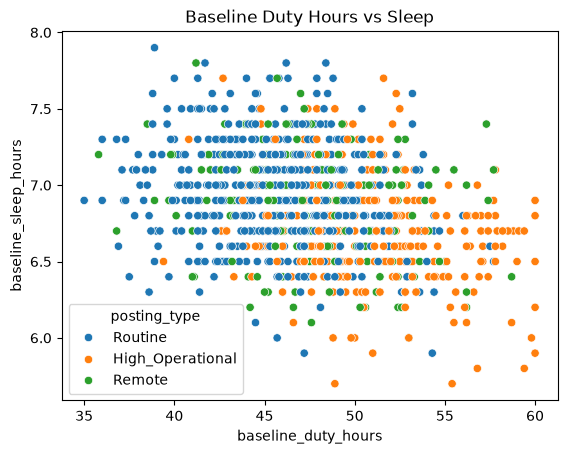

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x="baseline_duty_hours",
    y="baseline_sleep_hours",
    hue="posting_type"
)

plt.title("Baseline Duty Hours vs Sleep")
plt.show()

In [5]:
df.groupby("posting_type")[
    [
        "baseline_duty_hours",
        "baseline_sleep_hours",
        "baseline_stress",
        "baseline_fatigue"
    ]
].mean().round(2)

,baseline_duty_hours,baseline_sleep_hours,baseline_stress,baseline_fatigue
posting_type,,,,
High_Operational,50.78,6.71,2.42,2.41
Remote,47.89,6.87,2.38,2.29
Routine,45.72,6.95,2.30,2.21


In [6]:
df.groupby("role_category")[
    [
        "baseline_duty_hours",
        "baseline_sleep_hours",
        "baseline_stress",
        "baseline_fatigue"
    ]
].mean().round(2)

,baseline_duty_hours,baseline_sleep_hours,baseline_stress,baseline_fatigue
role_category,,,,
Administrative,44.71,6.91,2.29,2.23
Field,49.69,6.82,2.40,2.34
Support,46.60,6.91,2.32,2.22
Technical,47.68,6.87,2.34,2.28


In [7]:
import sys
sys.path.append("../")

from src.baseline import generate_personnel_baselines
from src.weekly_simulation import simulate_personnel_weeks

In [8]:
personnel = generate_personnel_baselines(10)

weekly_df = simulate_personnel_weeks(
    personnel,
    n_weeks=26
)

weekly_df.head()

,personnel_id,week_index,role_category,posting_type,service_tenure_months,week_type,duty_hours_week,overtime_hours,night_shifts,consecutive_duty_days,...,days_since_last_deployment,recent_deployment_count,leave_days_taken,days_since_last_leave,avg_sleep_hours,sleep_quality,self_reported_stress,fatigue_level,mood_score,recovery_feeling
0,P001,1,Support,High_Operational,191,Normal,48.8,3.9,0,2,...,139,0,0,21,7.1,4.0,2.8,2.5,2.1,4.1
1,P001,2,Support,High_Operational,191,Normal,49.5,3.5,0,4,...,146,0,0,28,7.1,4.9,2.3,2.9,2.4,4.1
2,P001,3,Support,High_Operational,191,Normal,49.4,3.9,0,4,...,153,0,0,35,6.8,4.4,3.4,2.4,2.1,3.8
3,P001,4,Support,High_Operational,191,Deployment,56.8,4.7,2,7,...,0,1,0,42,6.6,4.0,4.2,3.4,2.4,3.1
4,P001,5,Support,High_Operational,191,Normal,50.5,1.3,0,3,...,7,1,0,49,7.2,4.3,2.8,2.6,2.0,3.0


In [9]:
weekly_df = simulate_personnel_weeks(
    personnel,
    n_weeks=26
)

In [10]:
weekly_df[
    weekly_df["personnel_id"] == "P001"
][
    [
        "week_index",
        "week_type",
        "duty_hours_week",
        "night_shifts",
        "avg_rest_hours",
        "leave_days_taken",
        "days_since_last_leave",
        "days_since_last_deployment",
        "recent_deployment_count",
        "avg_sleep_hours",
        "self_reported_stress",
        "fatigue_level"
    ]
]

,week_index,week_type,duty_hours_week,night_shifts,avg_rest_hours,leave_days_taken,days_since_last_leave,days_since_last_deployment,recent_deployment_count,avg_sleep_hours,self_reported_stress,fatigue_level
0,1,Normal,52.1,1,10.9,0,46,107,0,7.1,2.7,2.8
1,2,Normal,52.3,1,11.0,0,53,114,0,6.8,3.3,2.8
2,3,Deployment,57.8,2,5.0,0,60,0,1,6.6,4.2,4.8
3,4,Recovery,44.3,0,12.5,3,0,7,1,7.5,2.5,2.3
4,5,Recovery,46.9,0,15.5,5,0,14,1,7.5,2.8,2.3
5,6,Normal,50.7,1,7.9,0,7,21,1,7.0,3.9,2.7
6,7,Normal,46.6,1,11.9,0,14,28,1,6.8,2.8,2.5
7,8,Normal,53.5,0,11.4,0,21,35,1,6.8,3.0,3.0
8,9,Normal,51.8,0,11.6,0,28,42,1,7.0,2.7,3.1
9,10,Normal,48.7,0,11.8,0,35,49,1,7.4,3.1,2.9


In [11]:
weekly_df.groupby("week_type")[
    [
        "duty_hours_week",
        "avg_sleep_hours",
        "avg_rest_hours",
        "self_reported_stress",
        "fatigue_level"
    ]
].mean().round(2)

# weekly_df.groupby("week_type").size()

,duty_hours_week,avg_sleep_hours,avg_rest_hours,self_reported_stress,fatigue_level
week_type,,,,,
Deployment,53.98,6.38,8.83,3.61,3.54
Normal,48.28,6.87,10.99,2.70,2.60
Operational_Spike,55.06,6.31,8.97,3.56,3.69
Recovery,43.28,7.43,13.36,2.25,2.02


In [12]:
weekly_df.groupby("week_type").size()

week_type
Deployment            32
Normal               164
Operational_Spike     45
Recovery              19
dtype: int64